# Total Time Spent on Test
Checks the time the candidate spend on the whole test. The test will be marked as "too slow" if the time it took was more than the mean plus the standard deviation and marked as "too fast" if the time it took was more than the mean minus the standard deviation. 

In [1]:
import pandas as pd
import pyodbc  
import matplotlib.pyplot as plt

## Import Data from csv

In [2]:
fca_question = pd.read_csv("../../../decoded_data/FCA/FactQuestionFCA.csv")

## Data Inspection

In [3]:
fca_question.head()

,QuestionKey,TestKey,Competence1Key,Competence2Key,Competence3Key,Competence4Key,ItemId,Answer1,Answer2,Answer3,TimeSpent
0,1,1,1,0,0,0,222,0,0,0,11
1,2,1,2,183,0,0,223,3,4,2,3
2,3,1,3,184,0,0,226,4,3,2,13
3,4,1,4,0,0,0,229,2,0,4,100
4,5,1,5,0,0,0,238,0,0,0,2


In [4]:
fca_question.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3035485 entries, 0 to 3035484
Data columns (total 11 columns):
 #   Column          Dtype
---  ------          -----
 0   QuestionKey     int64
 1   TestKey         int64
 2   Competence1Key  int64
 3   Competence2Key  int64
 4   Competence3Key  int64
 5   Competence4Key  int64
 6   ItemId          int64
 7   Answer1         int64
 8   Answer2         int64
 9   Answer3         int64
 10  TimeSpent       int64
dtypes: int64(11)
memory usage: 254.7 MB


## Data Preparation

In [5]:
df = fca_question[["TestKey", "TimeSpent"]]

df_timespent = df.groupby('TestKey')['TimeSpent'].sum().reset_index()
df_timespent.head()

,TestKey,TimeSpent
0,1,129
1,2,5892
2,3,2606
3,4,8922
4,5,5776


## Statistics
LET OP: hier gedaan op hele kleine steekproef, dit moet berekend worden op de populatie! 

In [6]:
mu = df_timespent.TimeSpent.mean()
sigma = df_timespent.TimeSpent.std()

print("Mean:", mu)
print("Standard deviation:", sigma)

Mean: 3417.0995351859256
Standard deviation: 2160.4901659627794


## Data Labelling

### Too slow
We will now figure out on which tests the candidate spent "too much time". 

In [9]:
too_slow = (df_timespent.TimeSpent > (mu + sigma) )

df_timespent['TooSlow'] = False
df_timespent.loc[too_slow, 'TooSlow'] = True

### Too fast
We will now figure out on which tests the candidate spent "too little time". 

In [10]:
too_fast = (df_timespent.TimeSpent < (mu - sigma) )

df_timespent['TooFast'] = False
df_timespent.loc[too_fast, 'TooFast'] = True

## Exporting Data with Anomaly Check

In [11]:
df_timespent

,TestKey,TimeSpent,TooSlow,TooFast
0,1,129,False,True
1,2,5892,True,False
2,3,2606,False,False
3,4,8922,True,False
4,5,5776,True,False
...,...,...,...,...
160059,160060,2091,False,False
160060,160061,1833,False,False
160061,160062,4497,False,False
160062,160063,2315,False,False


In [12]:
df_timespent['is_anomaly'] = df_timespent.TooFast | df_timespent.TooSlow
df_timespent.is_anomaly = df_timespent.is_anomaly.astype(int)
df_timespent.head()

,TestKey,TimeSpent,TooSlow,TooFast,is_anomaly
0,1,129,False,True,1
1,2,5892,True,False,1
2,3,2606,False,False,0
3,4,8922,True,False,1
4,5,5776,True,False,1


In [13]:
df_timespent.to_csv("../csv/time_spent_test_checked.csv", index=False)

## Visualisation

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

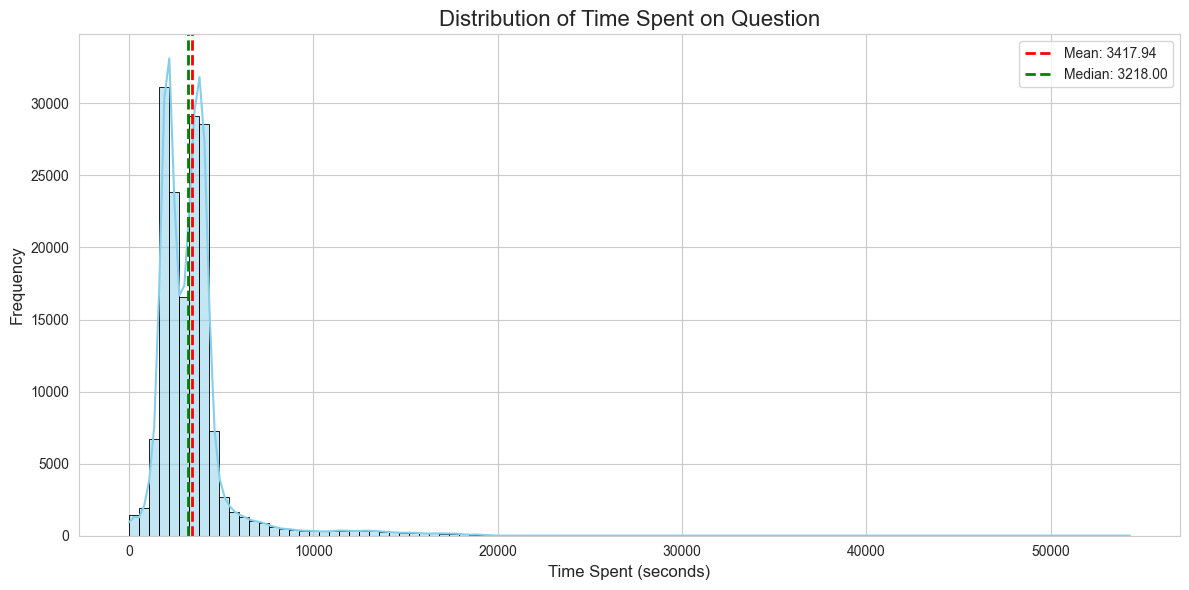

In [ ]:
sns.set_style("whitegrid")
plt.figure(figsize=(12, 6))

# kernel density estimation
sns.histplot(data=df_timespent, x='TimeSpent', kde=True, color='skyblue', edgecolor='black', bins=100)

# name 
plt.title('Distribution of Time Spent on Question', fontsize=16)
plt.xlabel('Time Spent (seconds)', fontsize=12)
plt.ylabel('Frequency', fontsize=12)

# Add summary statistics
mean_time = df_timespent['TimeSpent'].mean()
median_time = df_timespent['TimeSpent'].median()

plt.axvline(mean_time, color='red', linestyle='dashed', linewidth=2, label=f'Mean: {mean_time:.2f}')
plt.axvline(median_time, color='green', linestyle='dashed', linewidth=2, label=f'Median: {median_time:.2f}')

plt.legend()

# Adjust layout and display the plot
plt.tight_layout()
plt.show()

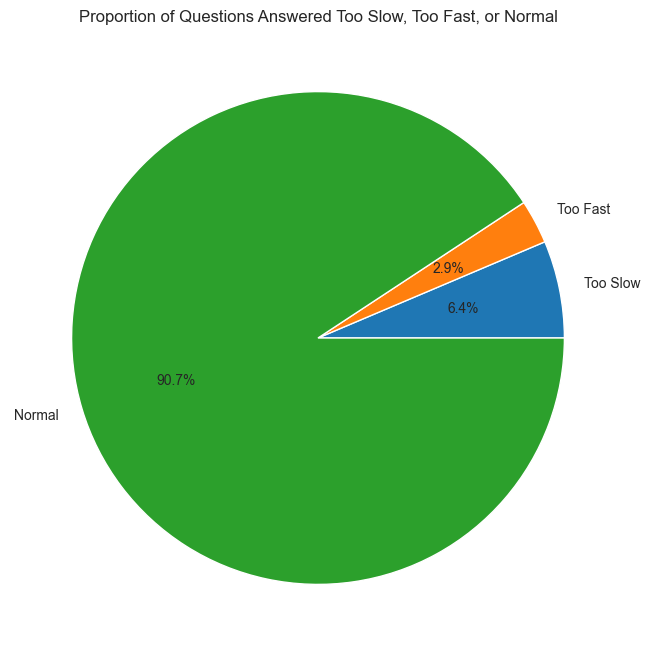

In [14]:
too_slow_count = df_timespent['TooSlow'].sum()
too_fast_count = df_timespent['TooFast'].sum()
normal_count = len(df_timespent) - too_slow_count - too_fast_count

plt.figure(figsize=(8, 8))
plt.pie([too_slow_count, too_fast_count, normal_count], 
        labels=['Too Slow', 'Too Fast', 'Normal'], 
        autopct='%1.1f%%')
plt.title('Proportion of Questions Answered Too Slow, Too Fast, or Normal')
plt.show()